<div style="text-align: center; font-size: 46px; color: GREEN;">
    <u><b>P671 NLP Sentimental Analysis</b></u>
</div>

## Business Objective:
Extracting sentiment from customer reviews on a product

In [6]:
#1.IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#2.LOAD DATA
df=pd.read_excel("dataset.xlsx")


In [9]:
#3.BASIC INFO
print(df.head())
print(df.info())
print(df.shape)

                                     title  rating  \
0                         Horrible product       1   
1  Camera quality is not like 48 megapixel       3   
2                                  Overall       4   
3                         A big no from me       1   
4            Put your money somewhere else       1   

                                                body  
0  Very disappointed with the overall performance...  
1                              Camera quality is low  
2  Got the mobile on the launch date,Battery must...  
3  1. It doesn't work with 5.0GHz WiFi frequency....  
4  Not worth buying....faulty software, poor disp...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None
(14

In [10]:
#4. MISSING VALUES
print(df.isnull().sum())


title     0
rating    0
body      0
dtype: int64


In [18]:
#Drop missing reviews
df.rename(columns={'body':'review'},inplace=True)
df=df.dropna(subset=['review'])


In [21]:
#5.DUPLICATES
print("Duplicates:",df.duplicated().sum())



Duplicates: 0


In [22]:
#6.REVIEW LENGTH ANLYSIS
df['review_length']=df['review'].apply(lambda x:len(str(x)))

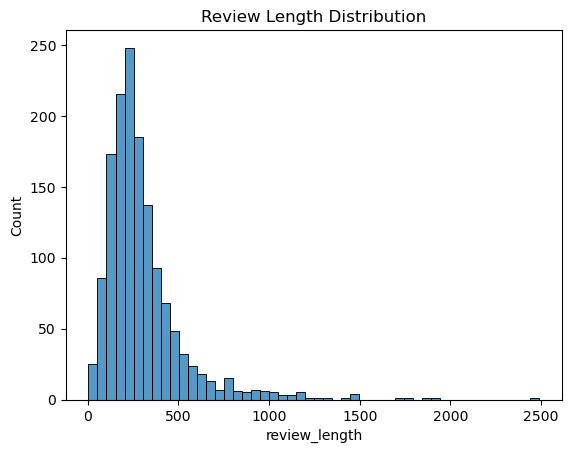

In [23]:
plt.figure()
sns.histplot(df['review_length'],bins=50)
plt.title("Review Length Distribution")
plt.show()

In [26]:
#7.WORD COUNT
df['word_count']=df['review'].apply(lambda x: len(str(x).split()))

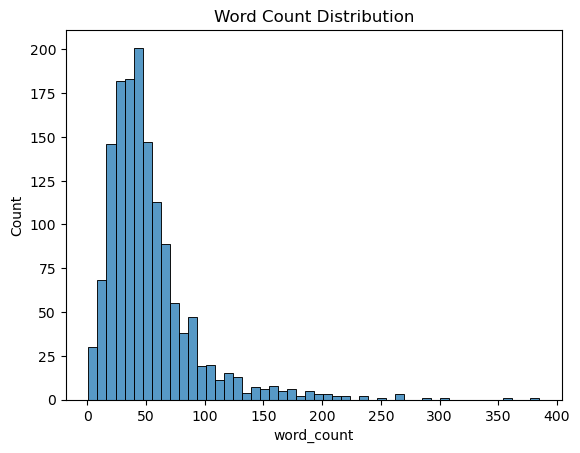

In [30]:
plt.figure()
sns.histplot(df['word_count'],bins=50)
plt.title("Word Count Distribution")
plt.show()

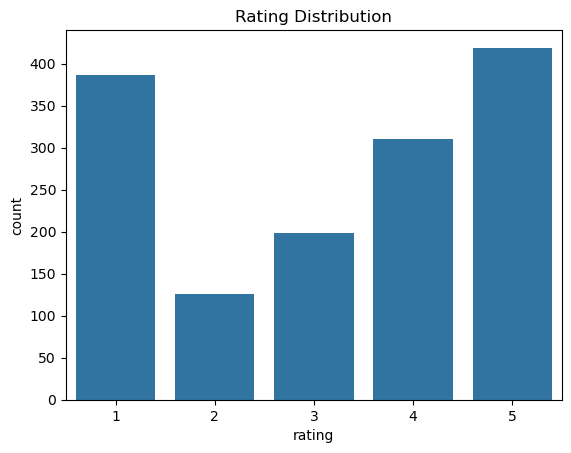

In [31]:
#8.RATING 
if 'rating' in df.columns:
    plt.figure()
    sns.countplot(x='rating',data=df)
    plt.title("Rating Distribution")
    plt.show()

In [32]:
#9.TEXT CLEANING REVIEW
print(df['review'].sample(5))

1281    The mobile with 6 GM RAM and 128 GB storage in...
421     अमेज़न मेने आपके ऐप्प सेsamsung M126GB Ram 128 ...
1347    It is working good & excellent.Camera quality ...
472     Mic Quality in video is extremely bad. Cannot ...
797     Everything with the phone is super nice apart ...
Name: review, dtype: object


In [33]:
#TEXT PREPROCESSING
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



In [34]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ranjithasijil/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ranjithasijil/nltk_data...


True

In [35]:
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))

In [37]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'[^a-zA-Z]',' ',text)
    words=text.split()
    words=[lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)
df['clean_review']=df['review'].apply(clean_text)

In [39]:
#SENTIMENT LABEL
if 'rating'in df.columns:
    def get_sentiment(rating):
        if rating >= 4:
            return "Positive"
        elif rating == 3:
            return "Neutral"
        else:
            return "Negative"
    df['sentiment']=df['rating'].apply(get_sentiment)
else:
    #fallback (simple rule)
    df['sentiment']="Positive" 

In [41]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=5000)

x=tfidf.fit_transform(df['clean_review']).toarray()
y=df['sentiment']

In [44]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [48]:
#MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

models={
    "Logistic Regression":LogisticRegression(max_iter=200),
    "Naive Bayes":MultinomialNB(),
    "SVM":SVC(),
    "Random Forest":RandomForestClassifier(),
    "KNN":KNeighborsClassifier()
}
results={}
trained_models={}

print("Model Performance:")

for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)
    results[name]=acc
    trained_models[name]=model

    print(f"{name}:{acc:.4f}")

Model Performance:
Logistic Regression:0.7743
Naive Bayes:0.6771
SVM:0.7674
Random Forest:0.7361
KNN:0.3854


In [50]:
#BEST MODEL
best_model_name=max(results,key=results.get)
best_model=trained_models[best_model_name]

print("\nBest Model:",best_model_name)




Best Model: Logistic Regression


In [55]:
#Evaluation
from sklearn .metrics import classification_report,confusion_matrix

y_pred=best_model.predict(x_test)

print("\nClassification report:\n")
print(classification_report(y_test,y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))


Classification report:

              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85       111
     Neutral       1.00      0.05      0.09        44
    Positive       0.72      0.95      0.82       133

    accuracy                           0.77       288
   macro avg       0.86      0.62      0.59       288
weighted avg       0.82      0.77      0.72       288

Confusion Matrix:
[[ 94   0  17]
 [  9   2  33]
 [  6   0 127]]


In [57]:
#SAVE MODEL
import pickle

pickle.dump(best_model,open("best_model.pkl","wb"))
pickle.dump(tfidf,open("tfidf.pkl","wb"))